In [11]:
import sys
try:
    import pyLOM
except ImportError as e:
    print(f'Error importing pyLOM: {e}')
    print('Importing with local repository')
    sys.path.append('/home/m.jaraiz/repos/pyLowOrder/')
from FotR import FRODO, SAM

def read_db_CODA(datafolder, case_idx, interpolate_vol2surf=True):
    db = FRODO(root_dir = datafolder, format = 'CODA', initial_parse = True)
    
    if interpolate_vol2surf:
        for id, type, var_excluded in zip([3, 4], ['surface', 'volume'], [[f'BoundaryValues_CoefSkinFriction{coord}' for coord in ['X', 'Y', 'Z']], []]):
            db.extract_inputs(
                id_groups = (id,),
                cases_idx = case_idx,
                vtu_type=type,
                verbose=False
                )

            for stage in [0, 1]:
                db.extract_outputs(
                    id_groups=(id,),
                    stage=stage, cases_idx = case_idx,
                    var_name_excluded = var_excluded,
                    vtu_type=type,
                    )
        
        db.sets.interpolate_vol2surf(
            vol_group = '4',
            surf_group = '3',
            stage = str(stage),
            vars = 'all',
        )
        
        db.sets.remove_data(id_group='4', stage=None, verbose=False)
    else:
        db.extract_inputs(
            id_groups = (3,),
            cases_idx = case_idx,
            vtu_type='surface',
            verbose=False
            )

        for stage in [0, 1]:
            db.extract_outputs(
                id_groups=(3,),
                stage=stage, cases_idx = case_idx,
                var_name_excluded = [f'BoundaryValues_CoefSkinFriction{coord}' for coord in ['X', 'Y', 'Z']],
                vtu_type='surface',
                )
    return db

from typing import Union
import os
def juntar_db(list_folders:Union[tuple[str], list[str]], case_idx:Union[tuple, list], name: str = None, interpolate_vol2surf:bool = True):
    list_db = []
    
    for folder, cases in zip(list_folders, case_idx):
        db = read_db_CODA(datafolder = folder, case_idx=cases, interpolate_vol2surf=interpolate_vol2surf)
        
        if db.data_dict['CADGroup_3']['FlCc'].shape[-1] > 2:
            flcc = db.data_dict['CADGroup_3']['FlCc'][:, :-1]
            design_vars = [var.lower() for var in db.metadata['design_vars']]
            db.metadata['design_vars'] = design_vars[:-1]
            db.data_dict['CADGroup_3']['FlCc'] = flcc
    
        list_db.append(db)
        
    db_full = FRODO.merge_datasets(
        root_dir=f'/home/m.jaraiz/Documentos/DATASETS/data_TIFON/{name}',
        name = name,
        sources = [(db, '3') for db in list_db], #[(db_0, '3'), (db_1, '3'), (db_trans, '3')],
        new_group_id='3_completo',
        k=4,
        mesh_ref=0,
        cache=True,
        get_df_metrics_attr={
            'var_metrics': ['CoefLift', 'CoefDrag', 'CoefMomentY'],
            'iter_var': 1000,
            'save' : False
        }
        
    )

    return db_full


Error importing pyLOM: No module named 'pyLOM'
Importing with local repository


0 Warning! Import - NVTX not present!


Comparar las bases de datos

In [12]:
isTest = False

if isTest:
    case_idx = list(range(6))
    tuple_cases = (case_idx, 'all', case_idx, case_idx)
    
else:
    # Base de datos original
    case_idx = list(range(100))
    fuera = [64, 79, 87, 88, 94]
    for c in fuera:
        case_idx.remove(c)

    tuple_cases = (case_idx, 'all', 'all', 'all') # original, rest, transonic, propose_0

In [13]:
list_folders = [
    os.path.join('/home/m.jaraiz/Documentos/DATASETS/data_TIFON/', folder) for folder in ['rans3_basic', 'rans3_basic_rest', 'rans3_transonic_1', 'rans3_propose_0']#['rans3_basic', 'rans3_basic_rest', 'rans3_transonic_1']
    ]

# list_db = [
#     read_db_CODA(
#         datafolder = root_dir,
#         case_idx = cases,
#         interpolate_vol2surf=False
#     ) for root_dir, cases in zip(list_folders, tuple_cases)
# ]

merge

In [14]:

## Con los 100 primeros no tengo problemas de repetición
name = "rans3_presentation"
db_completo = juntar_db(
    list_folders = list_folders,
    case_idx=tuple_cases,
    name = name,
    interpolate_vol2surf=False
)

# db_completo = juntar_db(
#     list_folders = [
#         os.path.join('/home/m.jaraiz/Documentos/DATASETS/data_TIFON/', folder) for folder in ['rans3_basic', 'rans3_basic_rest', 'rans3_transonic_1', 'rans3_propose_0']
#         ],
#     case_idx=tuple_cases,
#     name = name,
#     interpolate_vol2surf=False
# )


 NEW CODA SIMULATION WILL BE LOADED FROM /home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_basic
100 simulations found.
Parse took: 0.8613 s

 NEW CODA SIMULATION WILL BE LOADED FROM /home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_basic_rest
5 simulations found.
Parse took: 0.0637 s

 NEW CODA SIMULATION WILL BE LOADED FROM /home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_transonic_1
80 simulations found.
Parse took: 0.1558 s

 NEW CODA SIMULATION WILL BE LOADED FROM /home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_propose_0
100 simulations found.
Parse took: 0.1563 s

 NEW CODA SIMULATION WILL BE LOADED FROM /home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_presentation


In [ ]:
len(db_completo.metadata['df_cases'])

In [ ]:
path = f'/home/m.jaraiz/Documentos/DATASETS/data_TIFON/{name}/outputs'
db_completo.sets.create_NN_pylom(id_groups = '3_completo', stage='0', save_path = path)
db_completo.sets.create_NN_pylom(id_groups = '3_completo', stage='1', save_path = path)

In [ ]:
import pandas as pd
import os
df_post = pd.read_csv(
    filepath_or_buffer=f'/home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_{name}/metadata/df_post.csv',
    sep = ',',
    index_col=0
)
df_post['h'] = 11000
#remove the column coef_area
try:
    df_post = df_post.drop(columns=['coef_area'])
except:
    pass

df_post.to_csv(
    f'/home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_{name}/metadata/df_post.csv',
    sep=',',
    index_label = 'index',
    index=True,
)
# Cambiar de nombre un archivo

for stage in [0, 1]:
    old_name = f'/home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_{name}/outputs/CADGroup_3_completo_stage_{stage}.h5'
    new_name = f'/home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_{name}/outputs/CADGroup_#280_stage_{stage}.h5'

    os.rename(old_name, new_name)

In [1]:
import pandas as pd
import os
df_post = pd.read_csv(
    filepath_or_buffer=f'/home/airbus/CETACEO_cp_interp/TIFON/DATA/df_post.csv',
    sep = ',',
    index_col=0
)

In [2]:
print(df_post.columns)

Index(['aoa', 'mach', 'stage', 'case_idx', 'h', 're', 'folder',
       'coeflift_mean_stage0', 'coeflift_var_stage0', 'coefdrag_mean_stage0',
       'coefdrag_var_stage0', 'coefmomenty_mean_stage0',
       'coefmomenty_var_stage0', 'coeflift_mean_stage1', 'coeflift_var_stage1',
       'coefdrag_mean_stage1', 'coefdrag_var_stage1',
       'coefmomenty_mean_stage1', 'coefmomenty_var_stage1',
       'total_iter_stage0', 'cfl_stage0', 'densityresidual_stage0',
       'energystagnationdensityresidual_stage0', 'iteration_stage0',
       'momentumresidual_stage0', 'momentumxresidual_stage0',
       'momentumyresidual_stage0', 'momentumzresidual_stage0', 'time_stage0',
       'turbulentsanutildedensityresidual_stage0',
       'densityresidual_norm_stage0', 'densityresidual_scaled_stage0',
       'energystagnationdensityresidual_norm_stage0',
       'energystagnationdensityresidual_scaled_stage0',
       'momentumresidual_norm_stage0', 'momentumresidual_scaled_stage0',
       'momentumxresidual

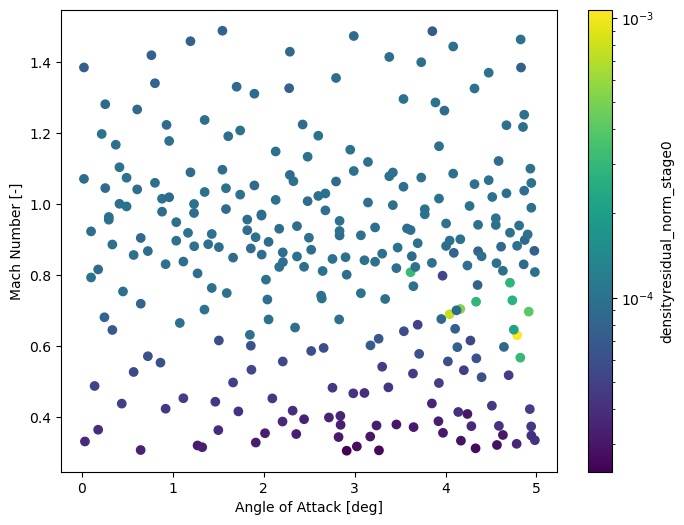

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

stage = 0
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

sc = ax.scatter(
    df_post['aoa'], df_post['mach'],
    #color
    c=df_post[f'densityresidual_norm_stage{stage}'],
    #norma logaritmica
    norm = mcolors.LogNorm(vmin=df_post[f'densityresidual_norm_stage{stage}'].min(), vmax=df_post[f'densityresidual_norm_stage{stage}'].max())
    
)
ax.set_xlabel('Angle of Attack [deg]')
ax.set_ylabel('Mach Number [-]')

fig.colorbar(sc, ax=ax, label=f'densityresidual_norm_stage{stage}')